# Дерево решений (классификатор)

Дерево решений — это алгоритм машинного обучения для классификации и регрессии. Оно строит модель в виде **дерева**, где каждый узел отвечает за проверку значения признака, каждая ветвь — за исход этой проверки, а листья — за итоговый класс объекта. Классификация нового объекта происходит через **последовательное прохождение по дереву** от корня к листу.

### Энтропия и информационная выгода

Для выбора оптимального признака на каждом узле используют **энтропию** и **информационную выгоду**.

Энтропия множества объектов \(S\) определяется как:

$$
H(S) = - \sum_{i=1}^{c} p_i \log_2 p_i
$$

Где:

- \(c\) — количество классов  
- \(p_i\) — доля объектов класса \(i\) в множестве \(S\)

Энтропия принимает значения от 0 до 1, где 1 означает большой хаос в данных (плохая энтропия)

Информационная выгода при разбиении узла S на подвыборки S1 и S2:

$$
IG(S) = H(S) - |S1|/|S| * H(S1) - |S2|/|S| * H(S2)
$$


Признак с наибольшей информационной выгодой выбирается для разбиения узла. Процесс повторяется рекурсивно для каждого подмножества до достижения **критерия остановки** (например, максимальной глубины дерева или минимального числа объектов в листе).

### Итог

Дерево решений создаёт **интерпретируемую модель**, где путь от корня до листа однозначно определяет класс нового объекта.

## Random Forest (Случайный лес) для классификации

**Random Forest** — это ансамблевый метод машинного обучения, основанный на множестве деревьев решений. Основная идея заключается в том, чтобы объединить предсказания многих деревьев для получения более точного и устойчивого результата по сравнению с отдельным деревом. Каждый классификатор в ансамбле строится на **случайной выборке данных** и **случайном подмножестве признаков**, что позволяет уменьшить переобучение и повысить стабильность модели.

### Алгоритм работы Random Forest

1. **Бэггинг (Bootstrap Aggregation)**  
   Для каждого дерева случайным образом выбирается подмножество объектов обучающей выборки с возвращением (bootstrap). Пусть обучающая выборка имеет \(n\) объектов, тогда для каждого дерева создаётся новое множество \(S_b\) того же размера:

   $$
   S_b \subset S, \quad |S_b| = n, \quad \text{выборка с возвращением}
   $$

2. **Случайный выбор признаков**  
   В каждом узле дерева рассматривается только случайное подмножество признаков размером \(m \ll p\), где \(p\) — общее число признаков. Среди этих признаков выбирается оптимальный по критерию (например, информационная выгода или джини-индекс).

3. **Обучение отдельных деревьев**  
   Каждое дерево строится полностью или до заранее заданной глубины, используя выбранные объекты и признаки.

4. **Агрегация предсказаний**  
   Для классификации итоговый класс определяется **голосованием большинства** деревьев:

   $$
   \hat{y} = \text{mode} \{ h_1(x), h_2(x), \dots, h_B(x) \}
   $$

   Где:

   - \(h_b(x)\) — предсказание \(b\)-го дерева для объекта \(x\)  
   - \(B\) — общее число деревьев в лесу  
   - \(\hat{y}\) — итоговый предсказанный класс  

### Преимущества Random Forest

- Устойчивость к переобучению за счёт ансамбля деревьев  
- Способность обрабатывать данные с большим числом признаков  
- Интерпретируемость через **важность признаков**  

Random Forest считается одним из самых эффективных методов классификации, особенно когда данные имеют сложные нелинейные зависимости и шум.

# Используемые библиотеки

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, recall_score, precision_score, make_scorer, f1_score

# Описание и демонстрация датасета

Датасет представляет из себя данные пациентов. Цель модели - предсказывать пациентов, у которых диабет

In [2]:
df = pd.read_csv('./data/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv')

# таргет
df['diabetic'] = df['diabetic'].map({'Yes': 1, 'No': 0})
y = df['diabetic']

# признаки (все столбцы кроме price)
X = df.drop(columns=['diabetic'])

In [3]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   str    
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 578.5

In [4]:
X.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0


Разобьем выборку на обучение и тест с помощью `train_test_split`

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=0.3)

X_train.shape, X_test.shape

((3701, 14), (1587, 14))

# Препроцессинг датасета

## Обработка NaN

Посмотрим еще раз на X


In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   str    
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 578.5

Пропусков нет

In [9]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3701 entries, 186 to 1289
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     3701 non-null   int64  
 1   gender                  3701 non-null   str    
 2   pulse_rate              3701 non-null   int64  
 3   systolic_bp             3701 non-null   int64  
 4   diastolic_bp            3701 non-null   int64  
 5   glucose                 3701 non-null   float64
 6   height                  3701 non-null   float64
 7   weight                  3701 non-null   float64
 8   bmi                     3701 non-null   float64
 9   family_diabetes         3701 non-null   int64  
 10  hypertensive            3701 non-null   int64  
 11  family_hypertension     3701 non-null   int64  
 12  cardiovascular_disease  3701 non-null   int64  
 13  stroke                  3701 non-null   int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 433.7 KB

In [10]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 1587 entries, 3121 to 1064
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1587 non-null   int64  
 1   gender                  1587 non-null   str    
 2   pulse_rate              1587 non-null   int64  
 3   systolic_bp             1587 non-null   int64  
 4   diastolic_bp            1587 non-null   int64  
 5   glucose                 1587 non-null   float64
 6   height                  1587 non-null   float64
 7   weight                  1587 non-null   float64
 8   bmi                     1587 non-null   float64
 9   family_diabetes         1587 non-null   int64  
 10  hypertensive            1587 non-null   int64  
 11  family_hypertension     1587 non-null   int64  
 12  cardiovascular_disease  1587 non-null   int64  
 13  stroke                  1587 non-null   int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 186.0 K

## Обработка категориальных признаков

### Gender

In [11]:
X_train['gender'].value_counts()

gender
Female    2636
Male      1065
Name: count, dtype: int64

## Преобразование признаков

### OHE

Для работы линейной регрессии нам необходимо, чтобы все признаки были числовыми.

Чтобы из категориальных признаков получить числовые, воспользуемся алгоритмом **One Hot Encoding**

In [12]:
NUM_COLUMNS = X_train.select_dtypes(include=np.number).columns.tolist()
CAT_COLUMNS = X_train.select_dtypes(include='object').columns.tolist()

print(NUM_COLUMNS)
print(CAT_COLUMNS)

['age', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'height', 'weight', 'bmi', 'family_diabetes', 'hypertensive', 'family_hypertension', 'cardiovascular_disease', 'stroke']
['gender']


/var/folders/xc/jjddd77s05z2dkp9dqhkrm580000gn/T/ipykernel_10450/151202149.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CAT_COLUMNS = X_train.select_dtypes(include='object').columns.tolist()


In [13]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3701 entries, 186 to 1289
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     3701 non-null   int64  
 1   gender                  3701 non-null   str    
 2   pulse_rate              3701 non-null   int64  
 3   systolic_bp             3701 non-null   int64  
 4   diastolic_bp            3701 non-null   int64  
 5   glucose                 3701 non-null   float64
 6   height                  3701 non-null   float64
 7   weight                  3701 non-null   float64
 8   bmi                     3701 non-null   float64
 9   family_diabetes         3701 non-null   int64  
 10  hypertensive            3701 non-null   int64  
 11  family_hypertension     3701 non-null   int64  
 12  cardiovascular_disease  3701 non-null   int64  
 13  stroke                  3701 non-null   int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 433.7 KB

In [14]:
# Создаём ColumnTransformer
ct = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_COLUMNS),   # категориальные
    ],
    remainder='passthrough',      # если есть ещё колонки, оставить их без изменений
    verbose_feature_names_out=False
)

# Fit-transform на train, transform на test
X_train = ct.fit_transform(X_train)
X_test  = ct.transform(X_test)

# Если результат sparse, преобразуем в массив
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
    X_test  = X_test.toarray()

# Создаём DataFrame с правильными колонками
X_train = pd.DataFrame(X_train, columns=ct.get_feature_names_out())
X_test  = pd.DataFrame(X_test,  columns=ct.get_feature_names_out())

In [15]:
# Train
X_train = X_train.astype(float)

# Test
X_test = X_test.astype(float)

In [16]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3701 entries, 0 to 3700
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender_Male             3701 non-null   float64
 1   age                     3701 non-null   float64
 2   pulse_rate              3701 non-null   float64
 3   systolic_bp             3701 non-null   float64
 4   diastolic_bp            3701 non-null   float64
 5   glucose                 3701 non-null   float64
 6   height                  3701 non-null   float64
 7   weight                  3701 non-null   float64
 8   bmi                     3701 non-null   float64
 9   family_diabetes         3701 non-null   float64
 10  hypertensive            3701 non-null   float64
 11  family_hypertension     3701 non-null   float64
 12  cardiovascular_disease  3701 non-null   float64
 13  stroke                  3701 non-null   float64
dtypes: float64(14)
memory usage: 404.9 KB


# Тепловая карта

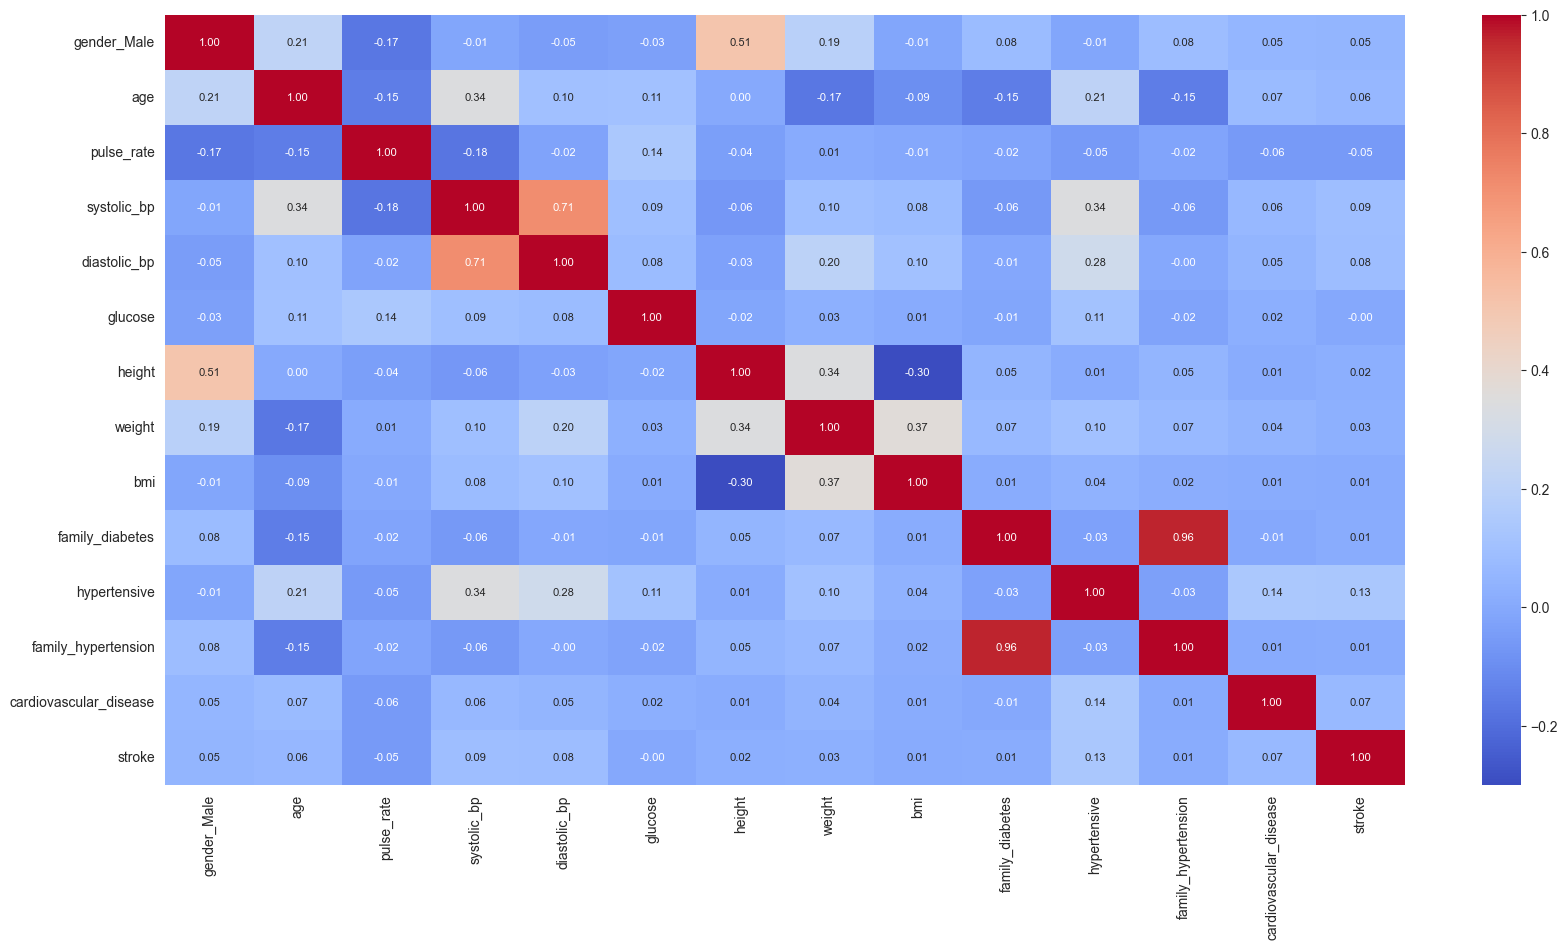

In [17]:

plt.figure(figsize=(20, 10))
sns.heatmap(
    X_train.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size":8},  # размер цифр
    xticklabels=X_train.columns,
    yticklabels=X_train.columns
)
plt.xticks(rotation=90)  # повернуть подписи по X
plt.yticks(rotation=0)   # по Y оставить горизонтально
plt.show()


Сильно коррелирующие признаки:


*   Inches_13 <-> Company_Huawei
*   Inches_13.5 <-> Company_Microsoft
*   OpSys_macOS <-> Company_Apple
*   GpuModel_ARM <-> CpuModel_Samsung
*   ScreenWidth <-> ScreenHeight




# Обучение модели

Обучаем модель

In [18]:
# Создаем кастомную метрику
def medical_score(y_true, y_pred):
    """
    Метрика для медицинской задачи:
    - Нам важно найти всех больных (высокий Recall)
    - Но мы штрафуем, если Precision падает ниже 0.2
    """
    recall = recall_score(y_true, y_pred, pos_label=1)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)

    # Если precision очень низкий, уменьшаем оценку
    if precision < 0.15:
        return recall * 0.5
    elif precision < 0.2:
        return recall * 0.8
    else:
        return recall

# Преобразуем в scorer для GridSearch
medical_scorer = make_scorer(medical_score)

In [19]:
# Создаем базовую модель
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Словарь с параметрами для перебора
param_grid = {
    'n_estimators': [100, 200, 300],        # количество деревьев
    'max_depth': [3, 5, 7, 10],              # максимальная глубина
    'min_samples_leaf': [5, 10, 20, 30],      # мин. объектов в листе
    'class_weight': [
        'balanced',                          # стандартный баланс
        {0: 0.5, 1: 5},                      # ручные веса (здоровые:больные)
        {0: 0.5, 1: 10},
        {0: 0.5, 1: 15}
    ]
}



# Создаем объект GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=medical_scorer,        # используем нашу медицинскую метрику
    cv=5,                          # 5-кратная кросс-валидация
    verbose=2,                      # показывать прогресс
    n_jobs=-1                       # использовать все ядра процессора
)

# Запускаем поиск (это может занять несколько минут!)
print("Начинаем подбор параметров...")
grid_search.fit(X_train, y_train)

# Результаты
print("\nЛучшие параметры:", grid_search.best_params_)

Начинаем подбор параметров...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=100; total time=   0.3s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=200; total time=   0.3s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=200; total time=   0.3s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=200; total time=   0.4s
[CV] END class_weight=balanced, max_depth=3, min_samples_leaf=5, n_estimators=200; total ti

Лучшие параметры: {'class_weight': {0: 0.5, 1: 15}, 'max_depth': 7, 'min_samples_leaf': 20, 'n_estimators': 200}



In [20]:
# Получаем вероятности
y_proba = grid_search.predict_proba(X_test)[:, 1]

# Задаем целевой recall (например, хотим находить минимум 90% больных)
TARGET_RECALL = 0.75

# Пробуем разные пороги
thresholds = np.arange(0.05, 0.6, 0.02)
results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    recall = recall_score(y_test, y_pred, pos_label=1)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    results.append({
        'threshold': threshold,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'meets_target': recall >= TARGET_RECALL
    })

# Смотрим результаты
df_results = pd.DataFrame(results)
print(f"Пороги с recall >= {TARGET_RECALL}:")
df_filtered = df_results[df_results['meets_target']].sort_values('precision', ascending=False)
print(df_filtered.to_string())

# Выбираем порог с максимальным precision среди удовлетворяющих recall
if len(df_filtered) > 0:
    best_row = df_filtered.iloc[0]
    best_threshold = best_row['threshold']

    print(f"\n✅ Лучший выбор:")
    print(f"Порог: {best_threshold:.3f}")
    print(f"Recall: {best_row['recall']:.3f} (цель достигнута!)")
    print(f"Precision: {best_row['precision']:.3f}")
    print(f"F1: {best_row['f1']:.3f}")

    # Финальные предсказания
    y_pred_final = (y_proba >= best_threshold).astype(int)
else:
    print(f"❌ Нет порогов с recall >= {TARGET_RECALL}")
    # Берем порог с максимальным recall
    best_row = df_results.loc[df_results['recall'].idxmax()]
    print(f"Берем порог с максимальным recall: {best_row['threshold']:.3f} (recall={best_row['recall']:.3f})")

Пороги с recall >= 0.75:
    threshold    recall  precision        f1  meets_target
27       0.59  0.765766   0.285235  0.415648          True
26       0.57  0.801802   0.277259  0.412037          True
25       0.55  0.837838   0.263456  0.400862          True
24       0.53  0.855856   0.246114  0.382294          True
23       0.51  0.873874   0.236010  0.371648          True
22       0.49  0.900901   0.232019  0.369004          True
21       0.47  0.900901   0.216920  0.349650          True
20       0.45  0.900901   0.203252  0.331675          True
19       0.43  0.909910   0.192381  0.317610          True
18       0.41  0.909910   0.179715  0.300149          True
17       0.39  0.927928   0.170813  0.288515          True
16       0.37  0.945946   0.163043  0.278146          True
15       0.35  0.963964   0.153736  0.265180          True
14       0.33  0.963964   0.144399  0.251174          True
13       0.31  0.972973   0.135678  0.238148          True
12       0.29  0.972973   0.126

In [21]:
def predict_with_threshold(model, X, threshold=0.5):
    """
    Предсказание с заданным порогом

    Parameters:
    -----------
    model : обученная модель sklearn
    X : данные для предсказания
    threshold : float, порог классификации (по умолчанию 0.5)

    Returns:
    --------
    array : предсказанные классы
    """
    # Получаем вероятности
    proba = model.predict_proba(X)

    # Для бинарной классификации
    return (proba[:, 1] >= threshold).astype(int)

# Тестирование модели

In [22]:
y_pred = predict_with_threshold(grid_search, X_test, 0.55)
y_proba = grid_search.predict_proba(X_test)[:, 1] # Вероятности для ROC-AUC

## Обзор метрик


### Базовые понятия (Confusion Matrix)

| Обозначение | Значение |
|-------------|----------|
| $TP$ | True Positive — верно предсказанные положительные классы |
| $TN$ | True Negative — верно предсказанные отрицательные классы |
| $FP$ | False Positive — ложные срабатывания (ошибка I рода) |
| $FN$ | False Negative — пропущенные положительные случаи (ошибка II рода) |

---

### Accuracy (Точность)
- **Определение:** Доля правильных предсказаний среди всех объектов.
- **Формула:**
  $$
  \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
  $$
- **Когда использовать:** Сбалансированные датасеты, когда важны оба класса одинаково.
- **Ограничения:** Вводит в заблуждение при дисбалансе классов.

### Precision (Точность предсказания)
- **Определение:** Доля истинно положительных среди всех предсказанных как положительные.
- **Формула:**
  $$
  \text{Precision} = \frac{TP}{TP + FP}
  $$
- **Когда использовать:** Когда важна минимизация ложных срабатываний (спам-фильтры).
- **Ограничения:** Не учитывает $FN$; может быть высокой за счёт низкой полноты.

### Recall (Полнота)
- **Определение:** Доля верно найденных положительных объектов среди всех реальных положительных.
- **Формула:**
  $$
  \text{Recall} = \frac{TP}{TP + FN}
  $$
- **Когда использовать:** Когда критично не пропускать положительные случаи (медицина, fraud).
- **Ограничения:** Может быть высокой за счёт увеличения $FP$.

### F1-Score (F-мера)
- **Определение:** Гармоническое среднее Precision и Recall.
- **Формула:**
  $$
  F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}
  $$
- **Когда использовать:** При дисбалансе классов и когда важны обе метрики.
- **Ограничения:** Не учитывает $TN$; не всегда отражает бизнес-требования.

### ROC-AUC (Area Under ROC Curve)
- **Определение:** Площадь под кривой зависимости TPR от FPR при изменении порога.
- **Формула (интегральная):**
  $$
  \text{AUC} = \int_0^1 \text{TPR}(FPR^{-1}(x)) \, dx
  $$
  где $\text{TPR} = \text{Recall}$, $\text{FPR} = \frac{FP}{FP + TN}$.
- **Когда использовать:** Сравнение моделей, работа с вероятностями.
- **Ограничения:** Менее информативен при сильном дисбалансе классов.

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1476
           1       0.26      0.84      0.40       111

    accuracy                           0.82      1587
   macro avg       0.62      0.83      0.65      1587
weighted avg       0.93      0.82      0.86      1587

